# CLIP for Image Classification and Similarity

This notebook uses the OpenAI **CLIP (Contrastive Language–Image Pre-training)** model for zero-shot image classification and image similarity tasks. For more details on CLIP, see the original CLIP paper by Radford et al. (2021): https://proceedings.mlr.press/v139/radford21a.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/6.3/clip.png)

# 1 - Imports and Model Loading

In [2]:
from PIL import Image
import requests
import torch
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

torch.set_printoptions(sci_mode=False)

config.json: 0.00B [00:00, ?B/s]

c:\Users\72786\anaconda3\envs\multimodal_ai\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\72786\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [4]:
import matplotlib.pyplot as plt
import math

# Utility functions
def load_image_from_path(path):
    # Open the image with PIL
    img = Image.open(path)
    return img
    

def display_images(images):
    """
    Displays a list of images in a dynamically calculated grid with image titles, in a compact layout.
    """
    # Calculate the number of rows required
    num_images = len(images)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for idx, image in enumerate(images):
        if image.mode == 'L':
            axes[idx].imshow(image, cmap='gray')
        else:
            axes[idx].imshow(image)
        axes[idx].set_title(f"Image {idx+1}")
        axes[idx].axis("off")
    plt.show()

# 2 - Zero-shot classification

The following cell demonstrates zero-shot image classification using CLIP. We input text prompts and an image, and the model returns image-text similarity scores. By applying softmax to these scores, we obtain probabilities indicating how likely each text description matches the image.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/6.3/clip-zeroshot.png)

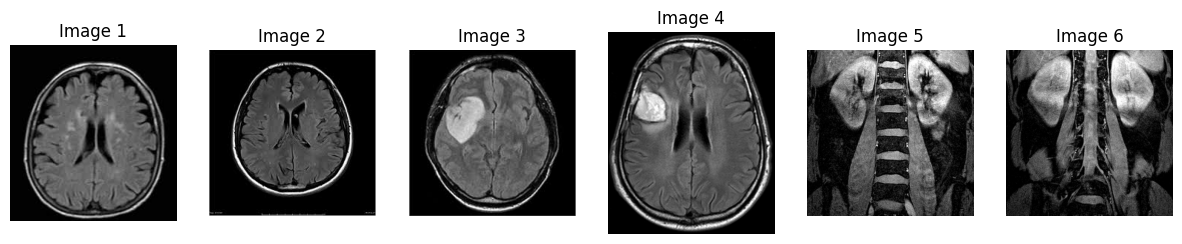

In [16]:
image1 = load_image_from_path("./data/samples/brain1.jpg")
image2 = load_image_from_path("./data/samples/brain2.jpg")
image3 = load_image_from_path("./data/samples/brain3.jpg")
image4 = load_image_from_path("./data/samples/brain4.jpg")
image5 = load_image_from_path("./data/samples/spine1.jpg")
image6 = load_image_from_path("./data/samples/spine2.jpg")

# Store the images in a list
images = [image1, image2, image3, image4, image5, image6]

display_images(images)

In [12]:
inputs = processor(
    text=["a brain mri", "a spine mri"],
    images=image4,
    return_tensors="pt",
    padding=True)

# input_ids: 2 tokenized labels/captions
inputs

{'pixel_values': tensor([[[[-1.7047, -1.7777, -1.6609,  ..., -1.7485, -1.7923, -1.7777],
          [-1.7485, -1.7923, -1.7047,  ..., -1.7047, -1.7923, -1.7777],
          [-1.7777, -1.7631, -1.5149,  ..., -1.6901, -1.7777, -1.7047],
          ...,
          [-1.6317, -1.3251, -0.9893,  ..., -1.1791, -1.4127, -1.4419],
          [-1.4711, -1.3543, -1.3105,  ..., -1.1353, -1.2959, -1.5441],
          [-1.2375, -1.3397, -1.2083,  ..., -1.0915, -1.5003, -1.3981]],

         [[-1.6621, -1.7371, -1.6170,  ..., -1.7071, -1.7521, -1.7371],
          [-1.7071, -1.7521, -1.6621,  ..., -1.6621, -1.7521, -1.7371],
          [-1.7371, -1.7221, -1.4669,  ..., -1.6470, -1.7371, -1.6621],
          ...,
          [-1.5870, -1.2718, -0.9267,  ..., -1.1218, -1.3619, -1.3919],
          [-1.4219, -1.3019, -1.2568,  ..., -1.0767, -1.2418, -1.4970],
          [-1.1818, -1.2869, -1.1518,  ..., -1.0317, -1.4519, -1.3469]],

         [[-1.3949, -1.4660, -1.3522,  ..., -1.4376, -1.4802, -1.4660],
          [-1

In [13]:
inputs.pixel_values.shape

torch.Size([1, 3, 224, 224])

In [14]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

probs

tensor([[0.0010, 0.9990]], grad_fn=<SoftmaxBackward0>)

In [17]:
inputs = processor(
    text=["a brain mri", "a spine mri"],
    images=images,
    return_tensors="pt",
    padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

probs

tensor([[0.9000, 0.1000],
        [0.9065, 0.0935],
        [0.8821, 0.1179],
        [0.8979, 0.1021],
        [0.0010, 0.9990],
        [0.0103, 0.9897]], grad_fn=<SoftmaxBackward0>)

# 3 - Image Similarity

In this section, we compute image similarity by obtaining image embeddings from CLIP.

Instead of classifying images to labels, we preprocess images to get **pixel_values**, then use **get_image_features** to generate embeddings.

The **cosine similarity** between these embeddings provides a similarity score between the two image:

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/6.3/cosine-similarity.png)



In [ ]:
# Obtain image embeddings

image1_preprocess = processor(images=image1, return_tensors="pt")['pixel_values']
image1_embedding = model.get_image_features( image1_preprocess)

image2_preprocess = processor(images=image2, return_tensors="pt")['pixel_values']
image2_embedding = model.get_image_features( image2_preprocess)

image1_embedding.shape

torch.Size([1, 512])

In [ ]:
import torch

similarity_score = torch.nn.functional.cosine_similarity(image1_embedding, image2_embedding)
similarity_score

tensor([1.0000], grad_fn=<SumBackward1>)

In [ ]:
import pandas as pd
import seaborn as sns

def compute_similarity(images):
    embeddings = []

    with torch.no_grad():
        for image in images:
            preprocess = processor(images=image, return_tensors="pt")['pixel_values']
            embedding = model.get_image_features(preprocess)
            embeddings.append(embedding)

    num_images = len(images)
    similarity_matrix = torch.zeros((num_images, num_images))

    with torch.no_grad():
        for i in range(num_images):
            for j in range(num_images):
                similarity_matrix[i, j] = torch.nn.functional.cosine_similarity(embeddings[i], embeddings[j])

    similarity_matrix = similarity_matrix.detach().numpy()
    image_labels = [f"Image {i+1}" for i in range(num_images)]
    similarity_df = pd.DataFrame(similarity_matrix, index=image_labels, columns=image_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(similarity_df, annot=True, cmap='Greens', linewidths=.5, cbar_kws={'label': 'Similarity'})
    plt.title("Image Similarity Heatmap")
    plt.show()

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for idx, image in enumerate(images):
        if image.mode == 'L':
            axes[idx].imshow(image, cmap='gray')
        else:
            axes[idx].imshow(image)
        axes[idx].set_title(f"Image {idx+1}")
        axes[idx].axis("off")

    plt.show()

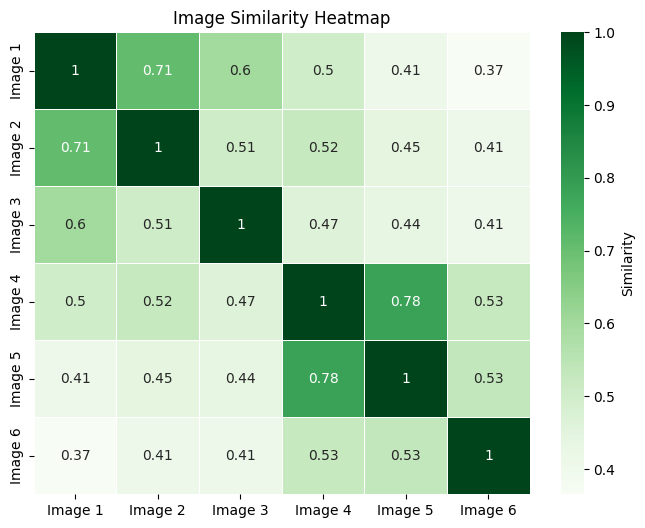

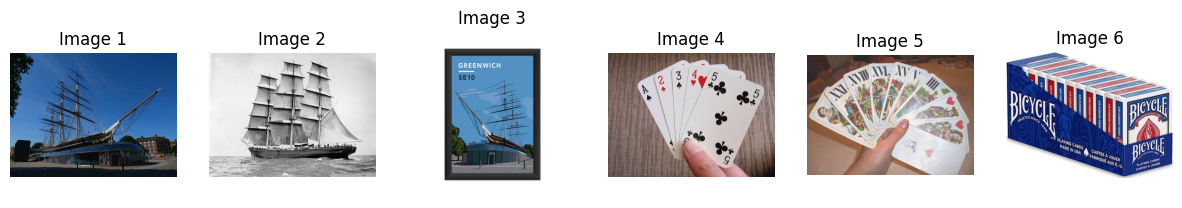

In [ ]:
compute_similarity(images)

#4 - Azure AI Studio

Azure AI Studio provides a model catalog (https://ai.azure.com/explore/models) with a large amounr of pre-trained models across different modalities. It allows you to deploy models easily, with some models available for serverless deployment, while others, like CLIP, require dedicated compute resources.

**Deployment Options**

The model catalog enables pay-as-you-go deployment for certain models. However, models like CLIP need dedicated infrastructure, so *it's important to delete resources after use to avoid ongoing charges for virtual machines*.

Once deployed, models can be accessed via Azure’s REST API for seamless integration into your applications.

In [ ]:
import base64
import requests

def image_to_base64(url):
    response = requests.get(url)
    return base64.b64encode(response.content).decode('utf-8')

In [ ]:
import urllib.request
import json
import os
import ssl
from google.colab import userdata

def allowSelfSignedHttps(allowed):
    # bypass the server certificate verification on client side
    if allowed and not os.environ.get('PYTHONHTTPSVERIFY', '') and getattr(ssl, '_create_unverified_context', None):
        ssl._create_default_https_context = ssl._create_unverified_context

allowSelfSignedHttps(True) # this line is needed if you use self-signed certificate in your scoring service.

# Request data goes here
# The example below assumes JSON formatting which may be updated
# depending on the format your endpoint expects.
# More information can be found here:
# https://docs.microsoft.com/azure/machine-learning/how-to-deploy-advanced-entry-script
data = {
  "input_data": {
    "data": [
      [
        image_to_base64("https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/6.3/cutty-sark-1.jpg"),
        "a ship, a photo of a ship in a frame, playing cards, a fan of playing cards"
      ]
    ],
    "columns": [
      "image",
      "text"
    ],
    "index": [
      0
    ]
  }
}

body = str.encode(json.dumps(data))

url = 'https://donatocapitella-5876-spzkb.eastus.inference.ml.azure.com/score'
# Replace this with the primary/secondary key, AMLToken, or Microsoft Entra ID token for the endpoint
api_key = ''
headers = {'Content-Type':'application/json', 'Authorization':('Bearer '+ api_key)}

req = urllib.request.Request(url, body, headers)

try:
    response = urllib.request.urlopen(req)

    result = response.read()
    print(result)
except urllib.error.HTTPError as error:
    print("The request failed with status code: " + str(error.code))

    # Print the headers - they include the requert ID and the timestamp, which are useful for debugging the failure
    print(error.info())
    print(error.read().decode("utf8", 'ignore'))


b'[{"probs": [0.5555867552757263, 0.4441460967063904, 0.00013270833005663007, 0.00013438731548376381], "labels": ["a ship", "a photo of a ship in a frame", "playing cards", "a fan of playing cards"]}]'
